# Lab: properties of random matrices (Trefethen & Bau, Exercise 12.3)

> A *random matrix* here is an $m \times m$ matrix whose entries are independent samples
> from the normal distribution with mean $0$ and standard deviation $m^{-1/2}$.
> The factor $\sqrt{m}$ makes the limiting behavior clean as $m \to \infty$.

Look for the following:

```python
# TODO
```

and is usually one or two lines. After each task there is a **Report** box — look for the following:

*Your answer here*

In [1]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

rng = np.random.default_rng(556)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'figure.constrained_layout.use': True})
theta = np.linspace(0, 2*np.pi, 400)

---
## Task 0 — the random matrix

Builds an $m \times m$ matrix whose entries are independent
$\mathcal{N}(0, 1/m)$ samples. Use `rng.standard_normal((m, m))`, which gives you
$\mathcal{N}(0,1)$ entries, and scale it.

In [4]:
def randmat(m, rng=rng):
    '''m x m matrix with independent N(0, 1/m) entries'''
    # TODO: return the scaled matrix
    return rng.standard_normal((m, m)) * np.sqrt(1/m)


# test
A = randmat(400)
assert A.shape == (400, 400)
assert abs(A.std() - 1/np.sqrt(400)) < 0.005, 'entries are not N(0, 1/m)'
print(f'entry std = {A.std():.5f},  1/sqrt(m) = {1/np.sqrt(400):.5f}   OK')

entry std = 0.04998,  1/sqrt(m) = 0.05000   OK


---
# (a) Plot the eigenvalues

## Task 1 — superimpose many samples

For each $m$, take **100 independent random matrices**, compute all their eigenvalues, and
plot them together in the complex plane.

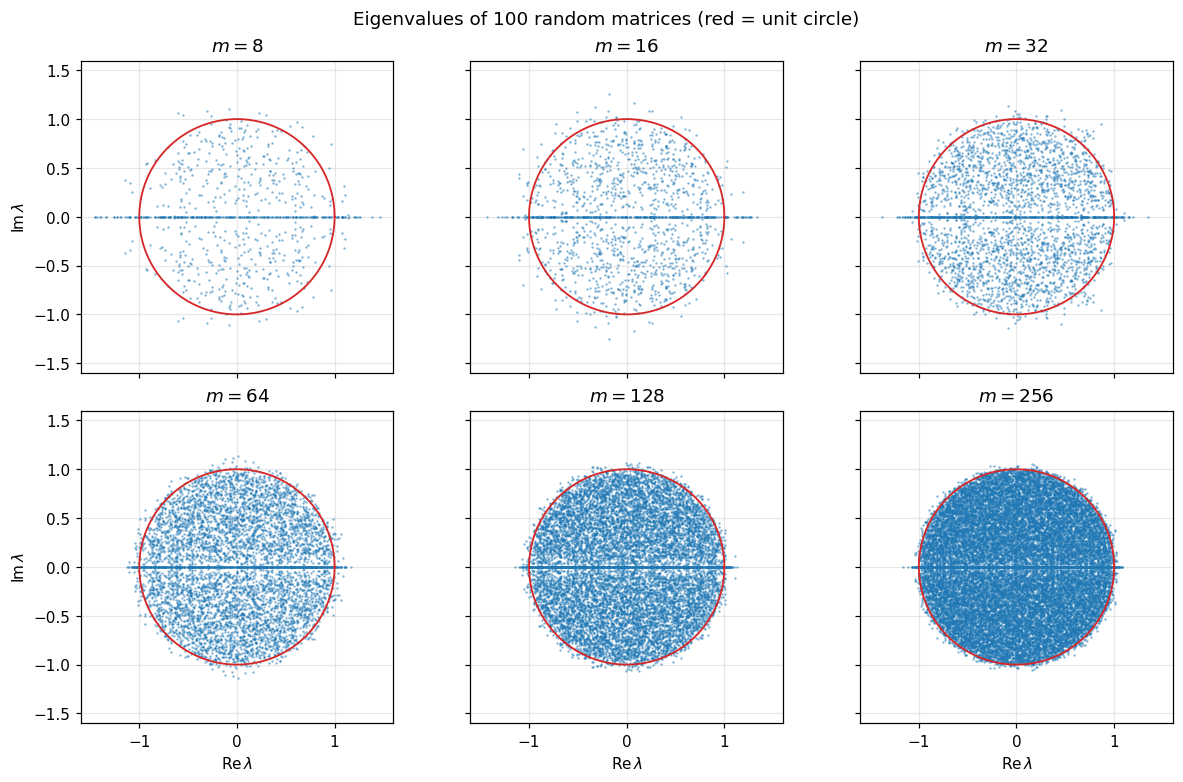

In [5]:
ms = [8, 16, 32, 64, 128, 256]
ntrials = 100

fig, axs = plt.subplots(2, 3, figsize=(11, 7), sharex=True, sharey=True)
eigs_by_m = {}

for ax, m in zip(axs.ravel(), ms):
    # TODO: all eigenvalues of `ntrials` independent random m x m matrices, in one array
    ev = np.array([la.eigvals(randmat(m)) for _ in range(ntrials)]).flatten()

    assert ev.shape == (ntrials*m,), f'expected {ntrials*m} eigenvalues, got {ev.shape}'
    eigs_by_m[m] = ev
    ax.plot(ev.real, ev.imag, '.', ms=1.2, alpha=0.5, color='tab:blue', rasterized=True)
    ax.plot(np.cos(theta), np.sin(theta), '-', lw=1.2, color='tab:red')
    ax.set_title(rf'$m={m}$')
    ax.set_aspect('equal'); ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)

for ax in axs[-1]:
    ax.set_xlabel(r'$\mathrm{Re}\,\lambda$')
for ax in axs[:, 0]:
    ax.set_ylabel(r'$\mathrm{Im}\,\lambda$')
fig.suptitle('Eigenvalues of 100 random matrices (red = unit circle)')
plt.show()

**Report (a1).** What region of the complex plane do the eigenvalues fill, and what happens
as $m$ grows?

They fill the unit square with "radius" 2 and as we increase $m$, it the eigenvalues fit tighter into the unit circle.

## Task 2 — uniformity

Is it really a disc? If the eigenvalues are uniformly distributed on
the unit disk, then the fraction with $|\lambda| \le r$ is exactly the area fraction
$r^2$. Plot the empirical fraction against that prediction.

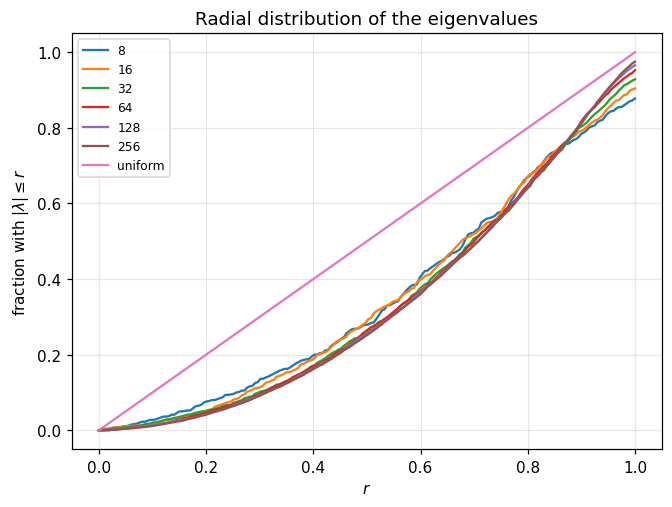

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.5))
r = np.linspace(0, 1, 200)

for m in ms:
    a = np.sort(np.abs(eigs_by_m[m]))
    # TODO: plot the fraction of eigenvalues with |lambda| <= r, against r
    ax.plot(r, np.searchsorted(a, r) / len(a), label=f"{m}")

# TODO: plot the prediction for a uniform distribution on the unit disk
ax.plot(r, r, label=f"uniform")

ax.set_xlabel(r'$r$'); ax.set_ylabel(r'fraction with $|\lambda| \leq r$')
ax.set_title('Radial distribution of the eigenvalues')
ax.legend(fontsize=8)
plt.show()

**Report (a2).** Do the curves approach the dashed prediction as $m$ grows? Where is the
agreement worst, and does that match what you noticed in Report (a1)?

*Your answer here.*

## Task 3 — the spectral radius

The spectral radius is $\rho(A) = \max_i |\lambda_i|$. Measure it as a function of $m$.

In [ ]:
ms_rho = 2**np.arange(2, 10)              # 4, 8, ..., 512
ntr = 30

rho = np.zeros((len(ms_rho), ntr))
for i, m in enumerate(ms_rho):
    for k in range(ntr):
        # TODO: the spectral radius of one random m x m matrix
        rho[i, k] = 0.0

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ms_rho, rho, '.', color='tab:gray', ms=3, alpha=0.5)
ax.plot(ms_rho, rho.mean(axis=1), 'o-', color='tab:blue', label=r'mean $\rho(A)$')
ax.axhline(1.0, color='tab:red', ls='--', label='1')
ax.set_xscale('log', base=2)
ax.set_xlabel('$m$'); ax.set_ylabel(r'$\rho(A)$')
ax.set_title('Spectral radius vs. $m$')
ax.legend()
plt.show()

print(f"{'m':>6} {'mean rho':>10} {'std':>8}")
for m, r_ in zip(ms_rho, rho):
    print(f'{m:6d} {r_.mean():10.4f} {r_.std():8.4f}')

**Report (a3).** What is your prediction:

> As $m \to \infty$, $\rho(A) \to$ *____* .

What happens to the *spread* (the standard deviation column) as $m$ grows? Roughly how
does it shrink (in terms of $m$)?

*Your answer here.*

---
# (b) What about the *norm*?

We have $\rho(A) \le \|A\|_2$. What happens as $m \to \infty$?

## Task 4 — measure both the norm and the spectral radius, and their ratio

In [ ]:
ms_n = 2**np.arange(2, 11)                # 4, 8, ..., 1024
ntr = 20

nrm  = np.zeros((len(ms_n), ntr))
rho2 = np.zeros((len(ms_n), ntr))
for i, m in enumerate(ms_n):
    for k in range(ntr):
        A = randmat(int(m))
        # TODO: the 2-norm and the spectral radius of this same matrix A
        nrm[i, k] = 0.0
        rho2[i, k] = 0.0

assert np.all(rho2 <= nrm + 1e-10), 'rho(A) <= ||A|| must hold for every sample!'

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].plot(ms_n, nrm.mean(axis=1), 'o-', label=r'mean $\|A\|_2$')
axs[0].plot(ms_n, rho2.mean(axis=1), 's-', label=r'mean $\rho(A)$')
axs[0].axhline(2.0, color='tab:red', ls='--', label='2')
axs[0].axhline(1.0, color='tab:orange', ls='--', label='1')
axs[0].set_xscale('log', base=2)
axs[0].set_xlabel('$m$'); axs[0].set_ylabel('value')
axs[0].set_title(r'$\|A\|_2$ and $\rho(A)$'); axs[0].legend(fontsize=8)

# TODO: plot the mean of the ratio rho(A) / ||A||_2 against m on axs[1]
pass

axs[1].axhline(0.5, color='tab:red', ls='--', label='1/2')
axs[1].set_xscale('log', base=2); axs[1].set_ylim(0, 1.05)
axs[1].set_xlabel('$m$'); axs[1].set_ylabel(r'$\rho(A)/\|A\|_2$')
axs[1].set_title('Is the inequality tight?'); axs[1].legend(fontsize=8)
plt.show()

print(f"{'m':>6} {'mean |A|_2':>11} {'mean rho':>10} {'ratio':>8}")
for m, n_, r_ in zip(ms_n, nrm, rho2):
    print(f'{m:6d} {n_.mean():11.4f} {r_.mean():10.4f} {(r_/n_).mean():8.4f}')

**Report (b1).** Fill in both blanks:

> As $m \to \infty$, $\|A\|_2 \to$ *____* , and $\rho(A)/\|A\|_2 \to$ *____* .

So does the inequality $\rho(A) \le \|A\|_2$ approach an equality? What does your answer
say about how far a random matrix is from being **normal**?

*Your answer here.*

---
# (e) Perturbing $A$

Now perturb a single entry. Take $m = 100$ and set $A_{00} = 1.5$.

Then run the Arnoldi iteration from `arnoldi.py` and plot the **Ritz values**.

## Task 9 — build the matrix

In [ ]:
from arnoldi import arnoldi

rng_e = np.random.default_rng(5)          # separate seed for this part

m = 100
A = randmat(m, rng_e)
# TODO: set the (0,0) entry to 1.5
pass

ev = la.eigvals(A)
i_out = np.argmax(np.abs(ev))             # index of the outlier eigenvalue

print(f'outlier eigenvalue      : {ev[i_out]:.4f}')
print(f'next largest in modulus : {np.sort(np.abs(ev))[-2]:.4f}')
assert np.abs(ev[i_out]) > 1.2, 'did you set A[0,0] = 1.5 ?'

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(ev.real, ev.imag, 'o', ms=5, color='tab:blue', label='eigenvalues')
ax.plot(np.cos(theta), np.sin(theta), '-', lw=1.2, color='tab:red', label='unit circle')
ax.set_aspect('equal')
ax.set_xlabel(r'$\mathrm{Re}\,\lambda$'); ax.set_ylabel(r'$\mathrm{Im}\,\lambda$')
ax.set_title(rf'$A$ with $A_{{00}}=1.5$, $m={m}$')
ax.legend(loc='upper left', fontsize=8)
plt.show()

**Report (e1).** Where is the outlier, and how big is the gap between it and the rest of
the spectrum? Is the outlier exactly at $1.5$? Why would you not expect it to be?

*Your answer here.*

## Task 10 — Ritz values for $k = 5, 6, \dots, 10$

Run Arnoldi for each $k$ **from the same starting vector**, and plot the Ritz values on top
of the true spectrum.

*Note:* With `V, H = arnoldi(A, k, v0=v0.copy())`, the Ritz values are `la.eigvals(H)`.
Passing a copy of `v0` — `arnoldi` normalizes its input in place.

In [ ]:
v0 = rng_e.standard_normal(m)             # the same starting vector for every k

ks = [5, 6, 7, 8, 9, 10]
fig, axs = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)

for ax, k in zip(axs.ravel(), ks):
    # TODO: run k steps of Arnoldi and compute the Ritz values
    ritz = None

    assert ritz.shape == (k,), f'expected {k} Ritz values'
    ax.plot(ev.real, ev.imag, 'o', ms=4, color='tab:blue', alpha=0.5, label='eigenvalues')
    ax.plot(ritz.real, ritz.imag, 'x', ms=10, mew=2, color='tab:red', label='Ritz values')
    ax.plot(np.cos(theta), np.sin(theta), '-', lw=1, color='0.6')
    ax.set_title(rf'$k={k}$')
    ax.set_aspect('equal'); ax.set_xlim(-1.7, 1.7); ax.set_ylim(-1.7, 1.7)

axs[0, 0].legend(loc='upper left', fontsize=8)
for ax in axs[-1]:
    ax.set_xlabel(r'$\mathrm{Re}\,\lambda$')
for ax in axs[:, 0]:
    ax.set_ylabel(r'$\mathrm{Im}\,\lambda$')
fig.suptitle('Ritz values from $k$ steps of Arnoldi, over the true spectrum')
plt.show()

**Report (e2).** Describe what the red $\times$'s do as $k$ increases.

1. What happens near the **outlier**?
2. What do the *other* Ritz values do — do they converge to particular eigenvalues of the
   bulk, or something else?

*Your answer here.*

## Task 11 — quantify the convergence

A picture suggests; a number confirms. For each $k$, measure the distance from the true
outlier eigenvalue to the *nearest* Ritz value.

*Hint:* `np.min(np.abs(ritz - ev[i_out]))`.

In [ ]:
kk = np.arange(2, 21)
err = []
for k in kk:
    V, H = arnoldi(A, int(k), v0=v0.copy())
    ritz = la.eigvals(H)
    # TODO: distance from ev[i_out] to the closest Ritz value
    err.append(np.nan)

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(kk, err, 'o-')
ax.set_xlabel('Arnoldi steps $k$')
ax.set_ylabel('error in the outlier eigenvalue')
ax.set_title('Convergence of the outlier Ritz value')
ax.set_xticks(kk[::2])
plt.show()

for k, e in zip(kk, err):
    print(f'k = {k:2d}   error = {e:.2e}')

**Report (e3).** How many Arnoldi steps buy you two correct digits in the outlier? Compare
that with $m = 100$, the number of steps a direct method would need.

Krylov methods converge first to eigenvalues that are **well separated** from the rest of
the spectrum. Using your plot from Task 9, explain why the spike is found quickly while the
$99$ eigenvalues in the disk are not.

*Your answer here.*